# Discrete event simulation: Cost-effectiveness of MIPAC Units compared to hospitals in Norway

This notebook implements a discrete event simulation to estimate the cost-effectiveness of treating acute care patients in Municipal Inpatient Acute Care Units (MIPACs) in Norway comapred to hospitals from a healthcare persepctive in Norway

The model used parameters based on data from Norwegian Health Directorate, Statistics Norway and National Patient Registry. The model has four different archetypes based on the data available and simulates admissions, length of stay, capacity constraints, costs and effects.


## The purpose of the model is to:
- Simulate arrival of patients to MIPAC units over one year period
- Model varying referral proportions of GPs to MIPAC units
- Account for limited capacity in MIPAC assuming no waiting
- Route the overflow of patients to hospitals
- Estimate the length of stay of patients, costs and effects

## Simulation overview

    - Time horizon: 365 days
    - Warm up period: No warm up period
    - Distribution used for arrival process: Exponential 
    - Distribution used for los: log-normal 
    - Unit of analysis: Individual patients
    - Output: Patient-level cost and functional improvement; others- LOS and pathway 
    - A fixed random seed set for ensuring reproducibility

## Care pathways

Patients follow one of three pathways:
1. MIPAC admission
   -Patient who is suitable for MIPAC
3. Hospital admission when the MIPAC beds are fully occupied
4. Direct hopsital admission for othe reasons than full occupancy


## Key assumptions

1.	All the patients in the model are assumed to be appropriate MIPAC patients.
2.	Patients do not wait for MIPAC beds i.e. they are immediately referred to hospital if there is no bed available. This was done to reflect reality where there is no negotiation on if the beds will be available in a few hours or so. 
3.	Hospital capacity is assumed to be unlimited. This is to reflect the absence of alternatives and obligation of hospitals to accept the patients in need of acute care even when they are full.
4.	Referral rate to MIPACs is assumed to be 70%. The difference in referral probabilities between GP office and OOH GP service not taken into account in the main model. 
5.	No seasonal patterns of admissions in MIPAC has been accounted for in the model. 
6.	Variations like intermunicipal collaboration and geography has not been taken into account in the main model for simplicity. 
7. Length of stay follows a lognormal distribution

## Key limitations:

1. Cost data:
2. 

In [1]:
import simpy
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
!pip install scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


In [25]:

# GLOBAL PARAMETERS
# ============================================================
sim_duration = 365  # days
warmup = 0            # days

sd_qaly_h=0.4
sd_qaly_m=0.3

# HOSPITAL PARAMETERS
# ============================================================

#cost data##
##transform the cost into log to use distribution while drawing random values of hospital cost data##

cost_ppat_h = 60681
sd_cost_h=92957
sig2_cost_h = np.log(1 + (sd_cost_h**2 / cost_ppat_h**2))
sig_cost_h  = np.sqrt(sig2_cost_h)
cost_epi_h   = np.log(cost_ppat_h) - 0.5 * sig2_cost_h

##QALY hospital##
qaly_h = 0.40
sd_qaly_h=0.40

##truncated normal distribution for qaly since the value has to be within 0 and 1
from scipy.stats import truncnorm

def rtruncnorm(mean, sd, low=0, high=1):
    a = (low - mean) / sd
    b = (high - mean) / sd
    return truncnorm.rvs(a, b, loc=mean, scale=sd)


##length of stay##
mean_los_h = 2.5
sd_los_h = 1.5

sig2_h = np.log(1 + (sd_los_h**2 / mean_los_h**2))

sig_los_h = np.sqrt(sig2_h)

mu_los_h = (    np.log(mean_los_h)    - 0.5 * sig2_h)

# ============================================================
# NORWEGIAN WTP
# ============================================================

wtp = 275000
WTP_upper = 825000

In [41]:
# MIPAC parameters

# ARCHETYPES
# ============================================================

Archetypes = pd.DataFrame({

    'archetypes':[1,2,3,4],

    'mean_adm_m':[28,110,96,420],

    'mean_los_m':[3.2,2.6,7.2,3.6],

    'sd_los_m':[0.89,0.83,7.68,1.45],

    'mu_los_m':[1.13,0.91,1.60,1.21],

    'sig_los_m':[0.27,0.31,0.87,0.39],

    'mean_beds_m':[1.2,2.2,2.8,9.8],

    'mean_cost_y':[
        1144789.25,
        2646801.11,
        2705353.50,
        8235351.13
    ],

    'qaly_m':[0.50,0.50,0.50,0.50],
    
    'sd_qaly_m':[0.3,0.3,0.3,0.3],

    'ref_prob_m':[0.70,0.70,0.70,0.70]
    

})

Archetypes['mean_costppat_m'] = (    Archetypes['mean_cost_y']    /    Archetypes['mean_adm_m'])


# CHOOSE ARCHETYPE
# ============================================================

k = 2 ##Choose between 1,2,3 and 4



# PARAMETER EXTRACTION
# ============================================================

def archetype_params(archetype):

    row = Archetypes.loc[Archetypes['archetypes'] == archetype].iloc[0]

    return {

        'mean_adm_m': row['mean_adm_m'],
        'mean_los_m':row['mean_los_m'],
        'mu_los_m': row['mu_los_m'],
        'sig_los_m': row['sig_los_m'],
        'mipac_capacity': max(0, int(round(row['mean_beds_m']))),
        'mean_costppat_m': row['mean_costppat_m'],
        'qaly_m': row['qaly_m'],
        'sd_qaly_m':row['sd_qaly_m'], 
        'ref_prob_m': row['ref_prob_m'],
        'mu_los_h': mu_los_h,
        'sig_los_h': sig_los_h,
        'cost_epi_h': cost_epi_h,
        'sig_cost_h': sig_cost_h,
        'qaly_h': qaly_h, 
        'sd_qaly_h':sd_qaly_h
        
    }

params = archetype_params(k)

In [42]:
print(Archetypes[['archetypes', 'mean_costppat_m']])

       

   archetypes  mean_costppat_m
0           1     40885.330357
1           2     24061.828273
2           3     28180.765625
3           4     19607.978881


In [43]:
# PATIENT ARRIVALS
# ============================================================
np.random.seed(123) ## to be able to reproduce the results while maintaining stochastic nature of simulation
random.seed(123)

def patient_gen(params, sim_duration, seed=None):

    arrivals = []
    t = 0
    pid = 0

    while t < sim_duration:

        interarrival = np.random.exponential(scale=365 / params['mean_adm_m'])
        t += interarrival
        if t >= sim_duration:
            break
        arrivals.append((pid,t))

        pid += 1

    return arrivals

# ============================================================
# STRATEGY ARM
# ============================================================

def patient_process_MIPAC(env, pid, arrival_time, MIPAC, params, stats):

    # Patient arrives
    yield env.timeout(arrival_time)

    # Default values
    t_in = None
    t_out = None

    # -----------------------------
    # 1. Referral decision
    # -----------------------------
    if np.random.random() <= params['ref_prob_m']:

        # -----------------------------------------
        # 2. If MIPAC has zero beds → force hospital
        # -----------------------------------------
        if params['mipac_capacity'] == 0:
            los = np.random.lognormal(params['mu_los_h'], params['sig_los_h'])
            yield env.timeout(los)

            pathway = "Direct_Hospital"  
            cost = np.random.lognormal(params['cost_epi_h'], params['sig_cost_h'])
            qaly = rtruncnorm(params['qaly_h'], params['sd_qaly_h'], 0, 1)

        else:
            # -----------------------------------------
            # 3. Try to request a MIPAC bed
            # -----------------------------------------
            with MIPAC.request() as req:
                result = yield req | env.timeout(0)

                if req in result:   # admitted to MIPAC
                    t_in = env.now

                    los = np.random.lognormal(params['mu_los_m'], params['sig_los_m'])
                    yield env.timeout(los)

                    t_out = env.now

                    pathway = "MIPAC"
                    cost = params['mean_costppat_m']
                    qaly = rtruncnorm(params['qaly_m'], params['sd_qaly_m'], 0, 1)

                else:               # no bed available
                    los = np.random.lognormal(params['mu_los_h'], params['sig_los_h'])
                    yield env.timeout(los)

                    pathway = "Hospital_NoBed"
                    cost = np.random.lognormal(params['cost_epi_h'], params['sig_cost_h'])
                    qaly = rtruncnorm(params['qaly_h'], params['sd_qaly_h'], 0, 1)

    # -----------------------------
    # 4. Not referred → hospital
    # -----------------------------
    else:
        los = np.random.lognormal(params['mu_los_h'], params['sig_los_h'])
        yield env.timeout(los)

        pathway = "Direct_Hospital"
        cost = np.random.lognormal(params['cost_epi_h'], params['sig_cost_h'])
        qaly = rtruncnorm(params['qaly_h'], params['sd_qaly_h'], 0, 1)

    # -----------------------------
    # 5. Store results (no warmup)
    # -----------------------------
    stats.append({
        'id': pid,
        'pathway': pathway,
        'cost': cost,
        'LOS': los,
        'qaly': qaly,
        't_MIPAC_in': t_in,
        't_MIPAC_out': t_out
    })

        
# ============================================================
# COMPARATOR ARM
# ============================================================

def patient_process_NoMIPAC(env,pid,arrival_time,params,stats):

    yield env.timeout(arrival_time)

    los = np.random.lognormal(params['mu_los_h'],params['sig_los_h'])

    yield env.timeout(los)

    cost = np.random.lognormal(params['cost_epi_h'], params['sig_cost_h'])
    
    qaly = rtruncnorm(params['qaly_h'], params['sd_qaly_h'], 0, 1)
    

    stats.append({

            'id': pid,

            'pathway': 'Hospital_Only',

            'cost': cost,

            'LOS': los,

            'qaly': qaly
        })

In [44]:
# RUN STRATEGY
# ============================================================

def run_strategy(arrivals,params):

    env = simpy.Environment()

    stats = []

    MIPAC = simpy.Resource(env,capacity=max(1,params['mipac_capacity']))

    for pid,arrival in arrivals:

        env.process(patient_process_MIPAC(env,pid,arrival,MIPAC,params,stats))

    env.run()

    total_time = env.now
 

    return pd.DataFrame(stats)

# RUN COMPARATOR
# ============================================================

def run_comparator(arrivals,params):

    env = simpy.Environment()

    stats = []

    for pid,arrival in arrivals:

        env.process(patient_process_NoMIPAC(env,pid,arrival,params,stats))

    env.run()

    return pd.DataFrame(stats)


In [45]:
# AGGREGATE
# ============================================================

def aggregate(df):

    return {

        'n':
            len(df),

        'mean_cost':
            df['cost'].mean(),

        'mean_qaly':
            df['qaly'].mean()
    }


# ICER
# ============================================================

def calc_icer(strategy,comparator):

    dc = (strategy['mean_cost']  -  comparator['mean_cost'])

    dq = (strategy['mean_qaly']  -  comparator['mean_qaly'])

    return {
        'Incremental Cost': dc,

        'Incremental QALY': dq,

        'ICER': dc/dq
    }

In [46]:

# BASE CASE
# ============================================================

arrivals = patient_gen(params, sim_duration)

df_strategy = run_strategy(arrivals,params)

df_comparator = run_comparator(arrivals,params)

agg_strategy = aggregate(df_strategy)

agg_comparator = aggregate(df_comparator)

results = calc_icer(agg_strategy,agg_comparator)

In [47]:
base_seed=123

def run_cea_once(params, sim_duration):

    arrivals = patient_gen(params, sim_duration)

    df_s = run_strategy(arrivals, params)
    df_c = run_comparator(arrivals, params)

    agg_s = aggregate(df_s)
    agg_c = aggregate(df_c)

    icer = calc_icer(agg_s, agg_c)

    return agg_s, agg_c, icer

In [48]:

# ============================================================
# OUTPUTS
# ============================================================

print("\nBASE CASE RESULTS")
print(results)

print("\nStrategy Pathways")
print(
    df_strategy['pathway']
    .value_counts()
)

print("\nComparator Pathways")
print(
    df_comparator['pathway']
    .value_counts()
)



BASE CASE RESULTS
{'Incremental Cost': np.float64(-38997.17868987184), 'Incremental QALY': np.float64(0.005950169742809708), 'ICER': np.float64(-6553960.70624653)}

Strategy Pathways
pathway
MIPAC              77
Direct_Hospital    37
Hospital_NoBed      5
Name: count, dtype: int64

Comparator Pathways
pathway
Hospital_Only    119
Name: count, dtype: int64
119
119
set()


In [49]:
# ============================================================
# OCCUPANCY FUNCTION
# ============================================================

def cluster_occupancy(df, capacity, sim_duration):
   
    df_use = df[df['t_MIPAC_in'].notna()].copy()
    df_use['mipac_time'] = df_use['t_MIPAC_out'] - df_use['t_MIPAC_in']

    T = sim_duration

    if capacity <= 0 or T <= 0:
        return 0.0

    if 'cluster' in df_use.columns:
        return df_use.groupby('cluster')['mipac_time'].sum() / (capacity * T)

    return df_use['mipac_time'].sum() / (capacity * T)


# ============================================================
# OVERFLOW FUNCTION
# ============================================================

def overflow_stats(df):
   
    referred = df['pathway'].isin(["MIPAC", "Hospital_NoBed"])
    total_referred = referred.sum()

    overflow = (df['pathway'] == "Hospital_NoBed").sum()

    if total_referred == 0:
        return 0.0

    return overflow / total_referred


# ============================================================
# PREPARE PARAMS WITH ARCHETYPE-SPECIFIC REFERRAL PROBABILITY
# ============================================================

# Correct lookup: use the chosen archetype k
ref_prob = float(
    Archetypes.loc[Archetypes['archetypes'] == k, 'ref_prob_m'].iloc[0]
)

# Inject into params
params['ref_prob_m'] = ref_prob


# ============================================================
# 200-REPLICATION PSA WITH COST, QALY, ICER, OCCUPANCY, OVERFLOW
# ============================================================

results = []

for rep in range(200):

    np.random.seed(10000 + rep)

    arrivals = patient_gen(params, sim_duration)

    df_s = run_strategy(arrivals, params)
    df_c = run_comparator(arrivals, params)

    agg_s = aggregate(df_s)
    agg_c = aggregate(df_c)

    dc = agg_s['mean_cost'] - agg_c['mean_cost']
    dq = agg_s['mean_qaly'] - agg_c['mean_qaly']
    icer = dc / dq if dq != 0 else np.nan

    occ = cluster_occupancy(
        df_s,
        capacity=params['mipac_capacity'],
        sim_duration=sim_duration
    )

    overflow_pct = overflow_stats(df_s)

    results.append({
    'rep': rep,
    'df_s': df_s,   # store full DES output
    'mean_cost_s': agg_s['mean_cost'],
    'mean_qaly_s': agg_s['mean_qaly'],
    'mean_cost_c': agg_c['mean_cost'],
    'mean_qaly_c': agg_c['mean_qaly'],
    'dc': dc,
    'dq': dq,
    'icer': icer,
    'occupancy': occ,
    'overflow_pct': overflow_pct
})


df_res = pd.DataFrame(results)


# ============================================================
# AGGREGATED RESULTS
# ============================================================

mean_dc = df_res['dc'].mean()
mean_dq = df_res['dq'].mean()
aggregated_icer = mean_dc / mean_dq

print("\n=== MEAN COST & QALY ACROSS 200 RUNS ===")
print(df_res[['mean_cost_s','mean_cost_c','mean_qaly_s','mean_qaly_c']].mean())

print("\n=== MEAN OCCUPANCY ACROSS 200 RUNS ===")
print(df_res['occupancy'].mean())

print("\n=== MEAN OVERFLOW (DUE TO NO BEDS) ACROSS 200 RUNS ===")
print(df_res['overflow_pct'].mean())
print(df_res['overflow_pct'].mean() * 100)

print("\n=== AGGREGATED ICER ===")
print(aggregated_icer)


=== MEAN COST & QALY ACROSS 200 RUNS ===
mean_cost_s    37568.853055
mean_cost_c    60335.195324
mean_qaly_s        0.484747
mean_qaly_c        0.455521
dtype: float64

=== MEAN OCCUPANCY ACROSS 200 RUNS ===
0.24561920312327284

=== MEAN OVERFLOW (DUE TO NO BEDS) ACROSS 200 RUNS ===
0.10353203395968158
10.353203395968158

=== AGGREGATED ICER (CORRECT METHOD) ===
-778968.5905287188


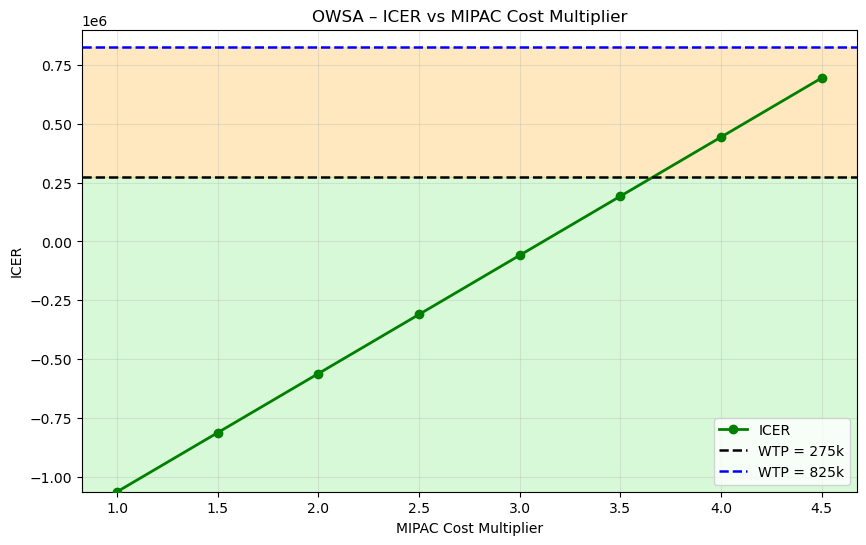

In [122]:
# ============================================================
# OWSA using cost per patient in MIPAC as the variable- 200 iterations
# ============================================================

cost_multipliers = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]

owsa_cost_psa = []

for m in cost_multipliers:

    dc_list = []
    dq_list = []

    for rep in range(200):

        np.random.seed(10000 + rep)   # fixed seed for reproducibility

        params_cost = params.copy()
        params_cost['mean_costppat_m'] = params['mean_costppat_m'] * m

        # Run DES
        arrivals = patient_gen(params_cost, sim_duration)
        df_s = run_strategy(arrivals, params_cost)
        df_c = run_comparator(arrivals, params_cost)

        agg_s = aggregate(df_s)
        agg_c = aggregate(df_c)

        dc = agg_s['mean_cost'] - agg_c['mean_cost']
        dq = agg_s['mean_qaly'] - agg_c['mean_qaly']

        dc_list.append(dc)
        dq_list.append(dq)

    # PSA-averaged ICER
    mean_dc = np.mean(dc_list)
    mean_dq = np.mean(dq_list)
    icer = mean_dc / mean_dq if mean_dq != 0 else np.nan

    owsa_cost_psa.append({
        'cost_multiplier': m,
        'mean_dc': mean_dc,
        'mean_dq': mean_dq,
        'ICER': icer
    })

owsa_cost_df = pd.DataFrame(owsa_cost_psa)


x = owsa_cost_df['cost_multiplier']
icer = owsa_cost_df['ICER']

plt.figure(figsize=(10,6))

# ------------------------------------------------------------
# 1. Set y-limits FIRST so shading doesn't hide WTP lines
# ------------------------------------------------------------
ymin = min(icer.min(), -800000)
ymax = max(icer.max(), 900000)
plt.ylim(ymin, ymax)

# ------------------------------------------------------------
# 2. Background shading (lowest z-order)
# ------------------------------------------------------------
plt.axhspan(ymin, 275000, color='lightgreen', alpha=0.35, zorder=1)
plt.axhspan(275000, 825000, color='orange', alpha=0.25, zorder=1)

# ------------------------------------------------------------
# 3. ICER curve (middle z-order)
# ------------------------------------------------------------
plt.plot(
    x,
    icer,
    marker='o',
    color='green',
    linewidth=2,
    zorder=3,
    label='ICER'
)

# ------------------------------------------------------------
# 4. WTP lines (highest z-order)
# ------------------------------------------------------------
plt.axhline(275000, linestyle='--', color='black', linewidth=1.8, zorder=10, label='WTP = 275k')
plt.axhline(825000, linestyle='--', color='blue', linewidth=1.8, zorder=10, label='WTP = 825k')

# ------------------------------------------------------------
# 5. Labels, grid, legend
# ------------------------------------------------------------
plt.title("OWSA – ICER vs MIPAC Cost Multiplier")
plt.xlabel("MIPAC Cost Multiplier")
plt.ylabel("ICER")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()




In [123]:
print(owsa_cost_df[['cost_multiplier', 'mean_dc', 'mean_dq', 'ICER']])


   cost_multiplier       mean_dc   mean_dq          ICER
0              1.0 -29143.956382  0.027396 -1.063786e+06
1              1.5 -22260.810951  0.027396 -8.125438e+05
2              2.0 -15377.665520  0.027396 -5.613015e+05
3              2.5  -8494.520089  0.027396 -3.100592e+05
4              3.0  -1611.374659  0.027396 -5.881693e+04
5              3.5   5271.770772  0.027396  1.924254e+05
6              4.0  12154.916203  0.027396  4.436676e+05
7              4.5  19038.061633  0.027396  6.949099e+05


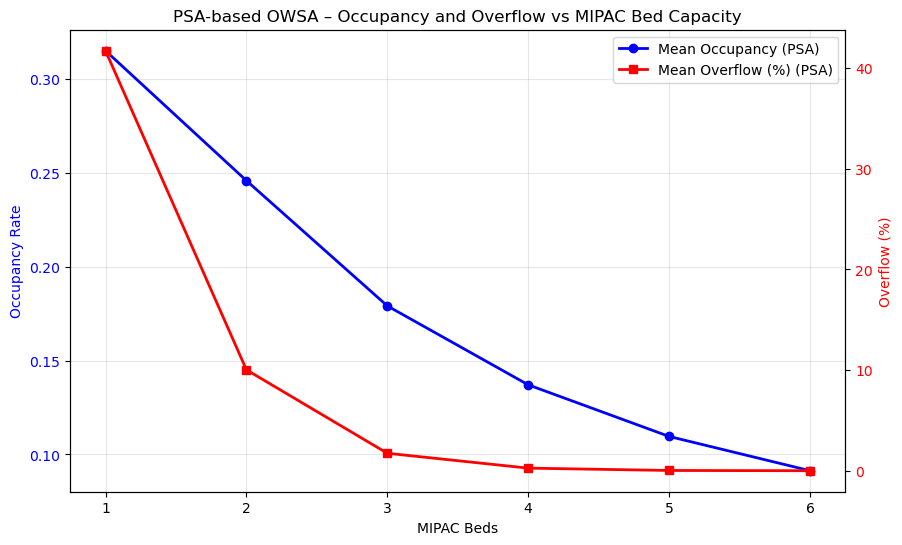

In [50]:
# ============================================================
# OWSA using beds as the variable to see effect on ICER- 200 iterations
# ============================================================

base_capacity = params['mipac_capacity']
bed_levels = list(range(max(1, base_capacity - 4), base_capacity + 5))

owsa_beds_psa = []

for beds in bed_levels:

    occ_list = []
    overflow_list = []
    dc_list = []
    dq_list = []

    for rep in range(200):

        np.random.seed(20000 + rep)   # reproducible PSA

        params_beds = params.copy()
        params_beds['mipac_capacity'] = beds

        # Run DES
        arrivals = patient_gen(params_beds, sim_duration)
        df_s = run_strategy(arrivals, params_beds)
        df_c = run_comparator(arrivals, params_beds)

        # Occupancy + Overflow
        occ = cluster_occupancy(df_s, beds, sim_duration)
        overflow = overflow_stats(df_s)

        # Cost + QALY
        agg_s = aggregate(df_s)
        agg_c = aggregate(df_c)

        dc = agg_s['mean_cost'] - agg_c['mean_cost']
        dq = agg_s['mean_qaly'] - agg_c['mean_qaly']

        occ_list.append(occ)
        overflow_list.append(overflow)
        dc_list.append(dc)
        dq_list.append(dq)

    # PSA means
    mean_occ = np.mean(occ_list)
    mean_overflow = np.mean(overflow_list)
    mean_dc = np.mean(dc_list)
    mean_dq = np.mean(dq_list)
    icer = mean_dc / mean_dq if mean_dq != 0 else np.nan

    owsa_beds_psa.append({
        'beds': beds,
        'mean_occupancy': mean_occ,
        'mean_overflow_pct': mean_overflow * 100,
        'mean_dc': mean_dc,
        'mean_dq': mean_dq,
        'ICER': icer
    })

owsa_beds_df = pd.DataFrame(owsa_beds_psa)


fig, ax1 = plt.subplots(figsize=(10,6))

# --- Occupancy (left axis) ---
ax1.plot(
    owsa_beds_df['beds'],
    owsa_beds_df['mean_occupancy'],
    marker='o',
    color='blue',
    linewidth=2,
    label='Mean Occupancy (PSA)'
)
ax1.set_xlabel("MIPAC Beds")
ax1.set_ylabel("Occupancy Rate", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- Overflow (right axis) ---
ax2 = ax1.twinx()
ax2.plot(
    owsa_beds_df['beds'],
    owsa_beds_df['mean_overflow_pct'],   # <<< FIXED
    marker='s',
    color='red',
    linewidth=2,
    label='Mean Overflow (%) (PSA)'
)
ax2.set_ylabel("Overflow (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Title and grid ---
plt.title("PSA-based OWSA – Occupancy and Overflow vs MIPAC Bed Capacity")
ax1.grid(True, alpha=0.3)

# --- Combined legend ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.show()


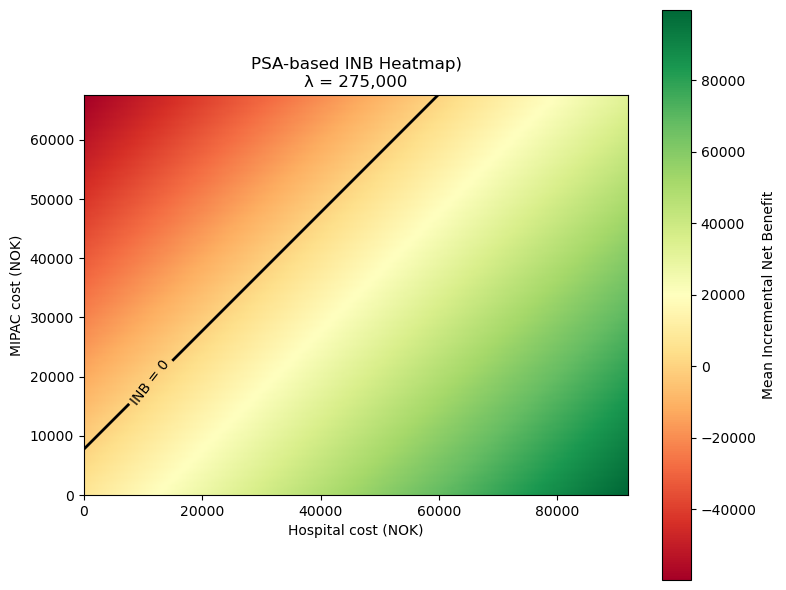

In [53]:
# ============================================================
# TWSA- using cost per patient in hospital and MIPAC to see the change in NMB, 200 iterations
# ============================================================

psa_results = []

for rep in range(200):

    np.random.seed(50000 + rep)

    arrivals = patient_gen(params, sim_duration)
    df_s = run_strategy(arrivals, params)
    df_c = run_comparator(arrivals, params)

    agg_s = aggregate(df_s)
    agg_c = aggregate(df_c)

    psa_results.append({
        'rep': rep,
        'Q_m': agg_s['mean_qaly'],
        'Q_h': agg_c['mean_qaly'],
        'C_m': agg_s['mean_cost'],
        'C_h': agg_c['mean_cost']
    })

df_psa = pd.DataFrame(psa_results)

# ============================================================
# PSA-BASED INB HEATMAP
# ============================================================

lam = wtp

# Cost ranges
C_hosp_vals  = np.linspace(0, df_psa['C_h'].mean() + 30000, 150)
C_mipac_vals = np.linspace(0, df_psa['C_m'].mean() + 30000, 150)

INB_mean = np.zeros((len(C_hosp_vals), len(C_mipac_vals)))

# Loop over replications
for idx, row in df_psa.iterrows():

    Q_h = row['Q_h']
    Q_m = row['Q_m']

    INB_rep = np.zeros_like(INB_mean)

    for i, C_hosp in enumerate(C_hosp_vals):
        for j, C_mipac in enumerate(C_mipac_vals):

            dQ = Q_m - Q_h
            dC = C_mipac - C_hosp

            INB_rep[i, j] = lam * dQ - dC

    INB_mean += INB_rep

# Average across 200 reps
INB_mean /= len(df_psa)


plt.figure(figsize=(8, 6))

im = plt.imshow(
    INB_mean.T,
    origin="lower",
    extent=[C_hosp_vals[0], C_hosp_vals[-1],
            C_mipac_vals[0], C_mipac_vals[-1]],
    cmap="RdYlGn"
)

plt.colorbar(im, label="Mean Incremental Net Benefit")

plt.xlabel("Hospital cost (NOK)")
plt.ylabel("MIPAC cost (NOK)")
plt.title(f"PSA-based INB Heatmap)\nλ = {lam:,.0f}")

# INB = 0 contour
CS = plt.contour(
    C_hosp_vals,
    C_mipac_vals,
    INB_mean.T,
    levels=[0],
    colors="black",
    linewidths=2
)
plt.clabel(CS, fmt="INB = 0", inline=True)

plt.tight_layout()
plt.show()


In [54]:
print(wtp, lam)

275000 275000


In [55]:
## to caculate how much lower should cost per patient in MIPAC be comapred to hospitals for NMB=>0

dQ_psa = df_psa['Q_m'].mean() - df_psa['Q_h'].mean()
C_m_threshold = lam * dQ_psa
print("PSA ΔQ:", dQ_psa)
print("Threshold MIPAC cost when hospital cost = 0:", C_m_threshold)


PSA ΔQ: 0.028089270271229594
Threshold MIPAC cost when hospital cost = 0: 7724.549324588138


## Probabilistic Sensitivity Analysis

Uncertainty in input parameters: Cost of both hospitals and MIPAC, QALY, referral probability

The distribution used for input parameters in PSA:

Cost--> Gamma distribution (mean and standard deviation)
Referral probability-->Beta distribution (alpha and beta)
QALY-->Beta distribution (mean utility and SD)

In [ ]:
print(params)

In [51]:
# ============================================================
# PROBABILISTIC SENSITIVITY ANALYSIS (PSA)
# ============================================================

n_psa = 1000
rng = np.random.default_rng(123)

psa_records = []

for i in range(n_psa):

    # Copy base parameters
    p = params.copy()

    # --------------------------------------------------------
    # 0. Arrival rate (Poisson around observed mean)
    # --------------------------------------------------------
    base_mean = p['mean_adm_m']
    p['mean_adm_m'] = max(1, rng.poisson(lam=base_mean))

    # --------------------------------------------------------
    # 1. Referral probability (Beta)
    # --------------------------------------------------------
    mean = p['ref_prob_m']
    sd   = 0.10 * mean   # assume 10% relative SD
    alpha = mean * ((mean * (1 - mean) / sd**2) - 1)
    beta  = (1 - mean) * ((mean * (1 - mean) / sd**2) - 1)
    p['ref_prob_m'] = rng.beta(alpha, beta)

    # --------------------------------------------------------
    # 2. MIPAC cost per patient (Gamma)
    # --------------------------------------------------------
    mean = p['mean_costppat_m']
    sd   = 0.20 * mean   # assume 20% SD for cost
    k     = (mean / sd)**2
    theta = sd**2 / mean
    p['mean_costppat_m'] = rng.gamma(k, theta)

    # --------------------------------------------------------
    # 3. MIPAC QALY (Truncated Normal)
    # --------------------------------------------------------
    mean = p['qaly_m']
    sd   = p['sd_qaly_m']
    p['qaly_m'] = rtruncnorm(mean, sd, 0, 1)

    # --------------------------------------------------------
    # 4. Hospital QALY (Truncated Normal)
    # --------------------------------------------------------
    mean = p['qaly_h']
    sd   = p['sd_qaly_h']
    p['qaly_h'] = rtruncnorm(mean, sd, 0, 1)

    # --------------------------------------------------------
    # 5. Hospital cost per patient (Lognormal using KNOWN mean & SD)
    # --------------------------------------------------------
    mean_h = cost_ppat_h      # 60681 (known mean)
    sd_h   = sd_cost_h        # 92957 (known SD)

    sigma2_h = np.log(1 + (sd_h**2 / mean_h**2))
    p['sig_cost_h'] = np.sqrt(sigma2_h)                      # σ
    p['cost_epi_h'] = np.log(mean_h) - 0.5 * sigma2_h        # μ

    # --------------------------------------------------------
    # Run DES for this PSA draw
    # --------------------------------------------------------
    agg_s, agg_c, icer = run_cea_once(p, sim_duration)

    # Net monetary benefit
    nmb_s = agg_s['mean_qaly'] * wtp - agg_s['mean_cost']
    nmb_c = agg_c['mean_qaly'] * wtp - agg_c['mean_cost']
    inmb  = nmb_s - nmb_c

    # --------------------------------------------------------
    # Store PSA results
    # --------------------------------------------------------
    psa_records.append({
        # sampled parameters
        'ref_prob_m': p['ref_prob_m'],
        'mean_costppat_m': p['mean_costppat_m'],
        'qaly_m': p['qaly_m'],
        'qaly_h': p['qaly_h'],

        # outcomes
        'cost_s': agg_s['mean_cost'],
        'qaly_s': agg_s['mean_qaly'],
        'cost_c': agg_c['mean_cost'],
        'qaly_c': agg_c['mean_qaly'],
        'dC': icer['Incremental Cost'],
        'dQ': icer['Incremental QALY'],
        'ICER': icer['ICER'],
        'NMB_s': nmb_s,
        'NMB_c': nmb_c,
        'INMB': inmb
    })

# Convert to DataFrame
psa_df = pd.DataFrame(psa_records)
print(psa_df.head())


   ref_prob_m  mean_costppat_m    qaly_m    qaly_h        cost_s    qaly_s  \
0    0.698613     20826.706880  0.441370  0.928288  35125.609951  0.532084   
1    0.690660     31843.215175  0.248542  0.562432  38015.995421  0.416989   
2    0.502581     27534.787759  0.806487  0.517027  49598.945377  0.590319   
3    0.738876     30098.232805  0.730681  0.373591  42365.532875  0.560539   
4    0.678518     27394.443543  0.724491  0.140885  38685.517989  0.530367   

         cost_c    qaly_c            dC        dQ           ICER  \
0  66651.501904  0.628407 -31525.891953 -0.096323  327294.135719   
1  73565.568425  0.576965 -35549.573003 -0.159976  222218.800663   
2  52637.595359  0.519223  -3038.649981  0.071096  -42740.124418   
3  82338.325254  0.474388 -39972.792379  0.086151 -463987.879955   
4  64079.292555  0.327791 -25393.774565  0.202576 -125354.596997   

           NMB_s          NMB_c          INMB  
0  111197.605549  106160.487273   5037.118275  
1   76656.085199   85099.7


Quadrant I (More effective, more costly):
  Cost‑effective: 9.4%
  Not cost‑effective: 4.3%

Quadrant III (Less effective, less costly):
  Cost‑effective: 14.5%
  Not cost‑effective: 21.0%


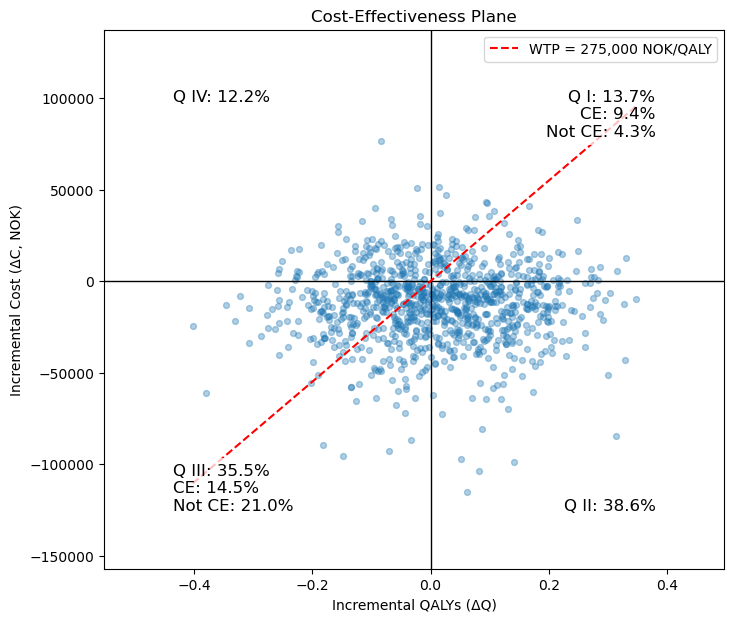

In [40]:
# ============================================================
# EXTRACT PSA ARRAYS
# ============================================================
dQ = psa_df["dQ"].to_numpy()
dC = psa_df["dC"].to_numpy()
N  = len(dQ)

# ============================================================
# PARAMETERS
# ============================================================
WTP = 275000

# ============================================================
# QUADRANT CLASSIFICATION
# ============================================================
quad_I   = (dQ > 0)  & (dC > 0)
quad_II  = (dQ > 0)  & (dC < 0)
quad_III = (dQ < 0) & (dC < 0)
quad_IV  = (dQ < 0) & (dC > 0)

# ============================================================
# COST-EFFECTIVE VS NOT (I & III)
# ============================================================
quad_I_ce      = quad_I  & (dC < WTP * dQ)
quad_I_not_ce  = quad_I  & (dC >= WTP * dQ)

quad_III_ce     = quad_III & (dC < WTP * dQ)
quad_III_not_ce = quad_III & (dC >= WTP * dQ)

pct_I_ce      = 100 * quad_I_ce.sum()     / N
pct_I_not_ce  = 100 * quad_I_not_ce.sum() / N

pct_III_ce      = 100 * quad_III_ce.sum()     / N
pct_III_not_ce  = 100 * quad_III_not_ce.sum() / N

# ============================================================
# QUADRANT PERCENTAGES (overall)
# ============================================================
pct_I   = 100 * quad_I.sum()   / N
pct_II  = 100 * quad_II.sum()  / N
pct_III = 100 * quad_III.sum() / N
pct_IV  = 100 * quad_IV.sum()  / N

# ============================================================
# PRINT SUMMARY
# ============================================================
print("\nQuadrant I (More effective, more costly):")
print(f"  Cost‑effective: {pct_I_ce:.1f}%")
print(f"  Not cost‑effective: {pct_I_not_ce:.1f}%")

print("\nQuadrant III (Less effective, less costly):")
print(f"  Cost‑effective: {pct_III_ce:.1f}%")
print(f"  Not cost‑effective: {pct_III_not_ce:.1f}%")

# ============================================================
# COST-EFFECTIVENESS PLANE
# ============================================================
plt.figure(figsize=(8,7))

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.scatter(dQ, dC, alpha=0.35, s=18, color='tab:blue')

q_line = np.linspace(dQ.min(), dQ.max(), 200)
plt.plot(q_line, WTP * q_line, '--', color='red',
         label=f"WTP = {WTP:,} NOK/QALY")

plt.xlabel("Incremental QALYs (ΔQ)")
plt.ylabel("Incremental Cost (ΔC, NOK)")
plt.title("Cost-Effectiveness Plane")

# TEXT LABELS AT THE EDGES
bbox_style = dict(facecolor='white', alpha=0.75, edgecolor='none')

xlim = plt.xlim()
ylim = plt.ylim()

# Quadrant I (top-right)
plt.text(xlim[1]*0.99, ylim[1]*0.99,
         f"Q I: {pct_I:.1f}%\nCE: {pct_I_ce:.1f}%\nNot CE: {pct_I_not_ce:.1f}%",
         fontsize=12, ha='right', va='top', bbox=bbox_style)

# TOP-LEFT → now Q IV
plt.text(xlim[0]*0.99, ylim[1]*0.99,
         f"Q IV: {pct_IV:.1f}%",
         fontsize=12, ha='left', va='top', bbox=bbox_style)

# Quadrant III (bottom-left) unchanged
plt.text(xlim[0]*0.99, ylim[0]*1.01,
         f"Q III: {pct_III:.1f}%\nCE: {pct_III_ce:.1f}%\nNot CE: {pct_III_not_ce:.1f}%",
         fontsize=12, ha='left', va='bottom', bbox=bbox_style)

# BOTTOM-RIGHT → now Q II
plt.text(xlim[1]*0.99, ylim[0]*1.01,
         f"Q II: {pct_II:.1f}%",
         fontsize=12, ha='right', va='bottom', bbox=bbox_style)


plt.legend()
plt.margins(x=0.2, y=0.2)
plt.show()


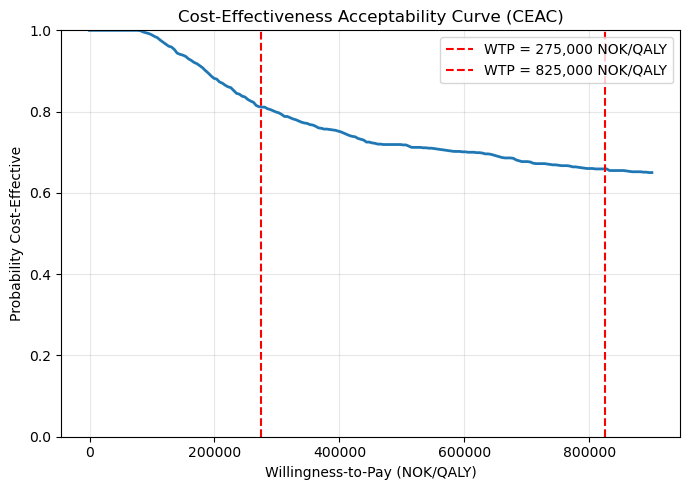

In [21]:
# ============================================
# CEAC
# ============================================

wtp_grid = np.linspace(0, 900000, 200)   # or any range you want

ceac = []

for wtp in wtp_grid:
    # Incremental Net Monetary Benefit
    incr_nmb = wtp * psa_df['dQ'] - psa_df['dC']
    p_ce = np.mean(incr_nmb > 0)
    ceac.append({'WTP': wtp, 'P_CE': p_ce})

ceac_df = pd.DataFrame(ceac)

# Plot CEAC
plt.figure(figsize=(7,5))
plt.plot(ceac_df['WTP'], ceac_df['P_CE'], linewidth=2)
plt.axvline(275000, color='red', linestyle='--', label='WTP = 275,000 NOK/QALY')
plt.axvline(825000, color='red', linestyle='--', label='WTP = 825,000 NOK/QALY')
plt.ylim(0,1)
plt.xlabel("Willingness-to-Pay (NOK/QALY)")
plt.ylabel("Probability Cost-Effective")
plt.title("Cost-Effectiveness Acceptability Curve (CEAC)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


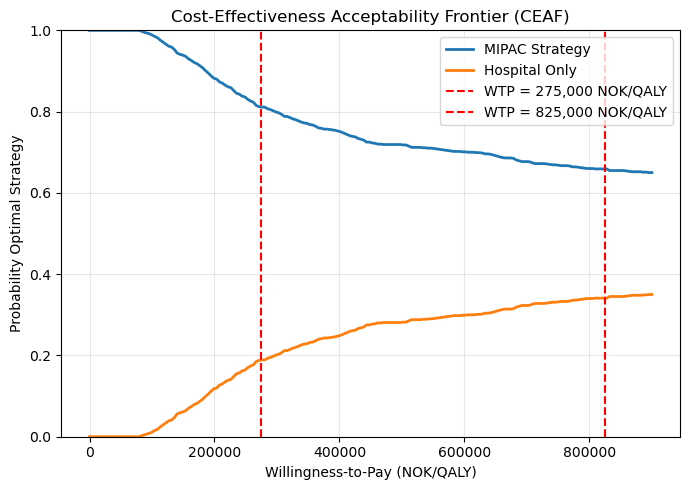

In [22]:
# ============================================
# CEAF
# ============================================

ceaf = []

for wtp in wtp_grid:
    # Net Monetary Benefit for each strategy
    nmb_s = psa_df['qaly_s'] * wtp - psa_df['cost_s']
    nmb_c = psa_df['qaly_c'] * wtp - psa_df['cost_c']

    # Which strategy is optimal in each PSA draw?
    optimal = np.where(nmb_s > nmb_c, 'Strategy', 'Comparator')

    ceaf.append({
        'WTP': wtp,
        'P_opt_strategy': np.mean(optimal == 'Strategy'),
        'P_opt_comparator': np.mean(optimal == 'Comparator')
    })

ceaf_df = pd.DataFrame(ceaf)

# Plot CEAF
plt.figure(figsize=(7,5))
plt.plot(ceaf_df['WTP'], ceaf_df['P_opt_strategy'], label="MIPAC Strategy", linewidth=2)
plt.plot(ceaf_df['WTP'], ceaf_df['P_opt_comparator'], label="Hospital Only", linewidth=2)
plt.axvline(275000, color='red', linestyle='--', label='WTP = 275,000 NOK/QALY')
plt.axvline(825000, color='red', linestyle='--', label='WTP = 825,000 NOK/QALY')
plt.ylim(0,1)
plt.xlabel("Willingness-to-Pay (NOK/QALY)")
plt.ylabel("Probability Optimal Strategy")
plt.title("Cost-Effectiveness Acceptability Frontier (CEAF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [52]:



# ---------------------------------------------------------
# 1. EVPI (Monte Carlo)
# ---------------------------------------------------------
def compute_evpi(psa_df, nmb_cols):
    nmb = psa_df[nmb_cols].values
    ev_perfect = np.max(nmb, axis=1).mean()
    ev_current = nmb.mean(axis=0).max()
    return ev_perfect - ev_current


# ---------------------------------------------------------
# 2. EVPPI for a single parameter (Gaussian Process)
# ---------------------------------------------------------
def compute_evppi_single_gp(psa_df, param_name, nmb_cols):
    X = psa_df[[param_name]].values      # S x 1
    Y = psa_df[nmb_cols].values          # S x T

    mu_list = []

    for t in range(Y.shape[1]):
        y = Y[:, t]

        kernel = C(1.0, (1e-3, 1e3)) * RBF(
            length_scale=[1.0],
            length_scale_bounds=(1e-3, 1e3)
        )

        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-6,
            normalize_y=True
        )

        gp.fit(X, y)
        mu_t = gp.predict(X)
        mu_list.append(mu_t)

    mu = np.column_stack(mu_list)

    evppi = mu.max(axis=1).mean() - Y.mean(axis=0).max()
    return evppi


# ---------------------------------------------------------
# 3. PREPARE NMB COLUMNS FOR YOUR PSA
# ---------------------------------------------------------
psa_df['NMB_s'] = psa_df['qaly_s'] * 20000 - psa_df['cost_s']
psa_df['NMB_c'] = psa_df['qaly_c'] * 20000 - psa_df['cost_c']

nmb_cols = ['NMB_s', 'NMB_c']


param_names = [
    'ref_prob_m',
    'mean_costppat_m',
    'qaly_m',
    'cost_epi_h',
    'qaly_h'
]


# ---------------------------------------------------------
# 4. RUN EVPI + EVPPI FOR EACH PARAMETER
# ---------------------------------------------------------
evpi_value = compute_evpi(psa_df, nmb_cols)
print("EVPI:", evpi_value)
print("\nEVPPI for each parameter:\n")

evppi_results = {}

for param in param_names:
    evppi_results[param] = compute_evppi_single_gp(psa_df, param, nmb_cols)
    print(f"{param}: {evppi_results[param]:.4f}")

# Optional: convert to DataFrame
evppi_df = pd.DataFrame.from_dict(evppi_results, orient='index', columns=['EVPPI'])
print("\nEVPPI Table:\n")
print(evppi_df)


EVPI: 104.77406159453312

EVPPI for each parameter:



C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445

ref_prob_m: 37.4109


C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


mean_costppat_m: 104.7735


C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


qaly_m: 96.8311


C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\sujan\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


KeyError: "None of [Index(['cost_epi_h'], dtype='str')] are in the [columns]"

## Only need to run the code below this once ##


In [80]:
## to find out what the ideal parameters are for each archetype

# ---------------------------------------------------------
# 1. Archetype parameters
# ---------------------------------------------------------
def archetype_params(archetype):

    row = Archetypes.loc[Archetypes['archetypes'] == archetype].iloc[0]

    return {

        # MIPAC arrivals & LOS
        'mean_adm_m': row['mean_adm_m'],
        'mean_los_m': row['mean_los_m'],     # ← optional but recommended
        'mu_los_m': row['mu_los_m'],
        'sig_los_m': row['sig_los_m'],

        # MIPAC capacity
        'mipac_capacity': max(0, int(round(row['mean_beds_m']))),

        # MIPAC costs & QALYs
        'mean_costppat_m': row['mean_costppat_m'],
        'qaly_m': row['qaly_m'],
        'sd_qaly_m': row['sd_qaly_m'],

        # Referral probability
        'ref_prob_m': row['ref_prob_m'],

        # Hospital LOS
        'mu_los_h': mu_los_h,
        'sig_los_h': sig_los_h,

        # Hospital costs
        'cost_epi_h': cost_epi_h,
        'sig_cost_h': sig_cost_h,

        # Hospital QALYs
        'qaly_h': qaly_h,
        'sd_qaly_h': sd_qaly_h
    }


# ---------------------------------------------------------
# 2. Build search grid (NO REFERRAL)
# ---------------------------------------------------------
def build_search_grid(archetype):
    p = archetype_params(archetype)

    base_adm  = p['mean_adm_m']
    base_beds = p['mipac_capacity']

    adm_range = np.linspace(base_adm * 0.5, base_adm * 3.0, 7).astype(int)
    bed_range = np.arange(max(1, base_beds - 5), base_beds + 3)

    return adm_range, bed_range

# ---------------------------------------------------------
# 3. Evaluate one design (ALL patients → MIPAC)
# ---------------------------------------------------------
def evaluate_design(mean_adm, beds, params, sim_duration, n_rep=10):

    util_list = []
    overflow_list = []
    incr_cost_list = []
    incr_qaly_list = []

    for r in range(n_rep):

        p = params.copy()
        p['mean_adm_m'] = mean_adm
        p['mipac_capacity'] = beds
        p['ref_prob_m'] = 1.0

        arrivals = patient_gen(p, sim_duration)

        df_strategy   = run_strategy(arrivals, p)
        df_comparator = run_comparator(arrivals, p)

        mipac_time = df_strategy.loc[df_strategy['pathway'] == 'MIPAC', 'LOS'].sum()
        util = mipac_time / (beds * sim_duration) if beds > 0 else 0

        referred = df_strategy['pathway'].isin(['MIPAC', 'Hospital_NoBed']).sum()
        overflow = (df_strategy['pathway'] == 'Hospital_NoBed').sum() / referred if referred > 0 else 0

        c_strat = df_strategy['cost'].sum()
        q_strat = df_strategy['qaly'].sum()
        c_comp  = df_comparator['cost'].sum()
        q_comp  = df_comparator['qaly'].sum()

        incr_cost_list.append(c_strat - c_comp)
        incr_qaly_list.append(q_strat - q_comp)
        util_list.append(util)
        overflow_list.append(overflow)

    return {
        'mean_adm': mean_adm,
        'beds': beds,
        'util_mean': np.mean(util_list),
        'overflow_mean': np.mean(overflow_list),
        'dC_mean': np.mean(incr_cost_list),
        'dQ_mean': np.mean(incr_qaly_list)
    }

# ---------------------------------------------------------
# 4. Run optimisation
# ---------------------------------------------------------
def optimise_archetype(archetype, params, sim_duration=365, n_rep=10):

    adm_range, bed_range = build_search_grid(archetype)
    results = []

    for mean_adm in adm_range:
        for beds in bed_range:
            res = evaluate_design(mean_adm, beds, params, sim_duration, n_rep)
            results.append(res)

    return pd.DataFrame(results)

# ---------------------------------------------------------
# 5. Pick IDEAL design
# ---------------------------------------------------------
def pick_ideal(df, wtp=275000):

    # Add ICER column
    df = df.copy()
    df['icer'] = df['dC_mean'] / df['dQ_mean']

    feasible = df[
        (df['dQ_mean'] > 0) &
        (df['icer'] <= wtp) &
        (df['util_mean'] >= 0.30) &
        (df['overflow_mean'] <= 0.40)
    ]

    if len(feasible) == 0:
        return None

    feasible = feasible.sort_values(
        ['mean_adm', 'beds', 'dC_mean', 'icer'],
        ascending=[False, True, True, True]
    )

    return feasible.head(1)

# ---------------------------------------------------------
# 6. Run everything
# ---------------------------------------------------------
archetype = 4

params = archetype_params(archetype)

df_res = optimise_archetype(archetype, params)
ideal = pick_ideal(df_res)

print("Ideal design for archetype", archetype)
print(ideal)


Ideal design for archetype 4
    mean_adm  beds  util_mean  overflow_mean       dC_mean    dQ_mean  \
46      1085    11   0.624237         0.3612 -2.735211e+07  32.411437   

             icer  
46 -843903.036849  


In [ ]:
## Effect of change in bed capacity on occupancy and overflow##


multipliers = [1, 2, 3, 4, 5, 6]

occ_results = []

for _, row in Archetypes.iterrows():

    arch = int(row['archetypes'])

    # Extract archetype parameters
    base_adm = row['mean_adm_m']
    mu = row['mu_los_m']
    sigma = row['sig_los_m']
    beds = int(round(row['mean_beds_m']))     # TRUE MIPAC capacity
    ref_prob = row['ref_prob_m']              # referral probability

    for m in multipliers:

        occ_list = []
        overflow_list = []

        # -------------------------------
        # 200 REPLICATIONS FOR STABILITY
        # -------------------------------
        for rep in range(20):

            params_arch = params.copy()
            params_arch['mean_adm_m'] = base_adm * m
            params_arch['mu_los_m'] = mu
            params_arch['sig_los_m'] = sigma
            params_arch['mipac_capacity'] = beds
            params_arch['ref_prob_m'] = ref_prob

            # Run DES
            arrivals = patient_gen(params_arch, sim_duration)
            df_s = run_strategy(arrivals, params_arch)

            # Time-based occupancy
            occ = cluster_occupancy(df_s, capacity=beds, sim_duration=sim_duration)

            # Overflow fraction
            overflow = overflow_stats(df_s)

            occ_list.append(occ)
            overflow_list.append(overflow)

        # Store MEAN across 200 reps
        occ_results.append({
            'archetype': arch,
            'multiplier': m,
            'occupancy': np.mean(occ_list),
            'overflow': np.mean(overflow_list)
        })

df_occ = pd.DataFrame(occ_results)

# ============================================================
# CREATE HEATMAP PIVOT TABLES
# ============================================================

heatmap_occ = df_occ.pivot(index='archetype', columns='multiplier', values='occupancy')
heatmap_overflow = df_occ.pivot(index='archetype', columns='multiplier', values='overflow')

# ============================================================
# PLOT OCCUPANCY HEATMAP
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_occ,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={'label': 'Mean Occupancy (0–1)'}
)
plt.title("Mean Time-based MIPAC Occupancy by Archetype")
plt.xlabel("Patient Multiplier")
plt.ylabel("Archetype")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT OVERFLOW HEATMAP
# ============================================================

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_overflow,
    annot=True,
    fmt=".2f",
    cmap="magma",
    cbar_kws={'label': 'Mean Overflow Fraction (0–1)'}
)
plt.title("Mean Overflow Probability by Archetype")
plt.xlabel("Patient Multiplier")
plt.ylabel("Archetype")
plt.tight_layout()
plt.show()
